
Training the Hidden Markov Model...

Means and variances:

Hidden state 1
Mean = 6.08
Variance = 0.22

Hidden state 2
Mean = 8.73
Variance = 0.73

Hidden state 3
Mean = 8.75
Variance = 0.71

Hidden state 4
Mean = 3.51
Variance = 1.07

Hidden state 5
Mean = 8.75
Variance = 0.72


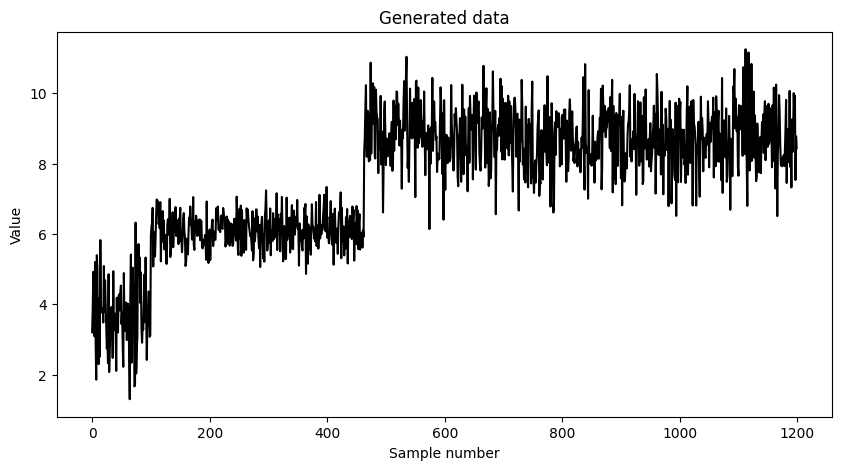

In [1]:
import datetime
import numpy as np
import matplotlib.pyplot as plt

from hmmlearn.hmm import GaussianHMM

# Create sample 1D data similar to textbook data_1D.txt
np.random.seed(5)

data = np.concatenate([
    np.random.normal(2.6, 0.5, 250),
    np.random.normal(4.4, 0.5, 250),
    np.random.normal(6.1, 0.5, 250),
    np.random.normal(8.0, 0.5, 250),
    np.random.normal(9.4, 0.5, 250)
])

X = data.reshape(-1, 1)

# Create Gaussian HMM with 5 hidden states
num_components = 5

hmm = GaussianHMM(
    n_components=num_components,
    covariance_type="diag",
    n_iter=1000,
    random_state=5
)

# Train the HMM
print("\nTraining the Hidden Markov Model...")
hmm.fit(X)

# Print mean and variance for each hidden state
print("\nMeans and variances:")

for i in range(hmm.n_components):
    print("\nHidden state", i + 1)
    print("Mean =", round(hmm.means_[i][0], 2))
    print("Variance =", round(np.diag(hmm.covars_[i])[0], 2))

# Generate 1200 samples
num_samples = 1200
generated_data, _ = hmm.sample(num_samples)

# Plot generated data
plt.figure(figsize=(10, 5))
plt.plot(np.arange(num_samples), generated_data[:, 0], c="black")
plt.title("Generated data")
plt.xlabel("Sample number")
plt.ylabel("Value")
plt.show()